In [29]:
import os
import numpy as np
import pandas as pd

In [30]:
root_dir = "/kaggle/input/timeseries-dataset/Timeseries_dataset"

# Subfolders
timeseries_dir = f"{root_dir}/timeseries"
csv_dir = f"{root_dir}/csv_file"
root1_dir = "/kaggle/working"
preprocessed_dir = f"{root1_dir}/left_2s_10"
os.makedirs(preprocessed_dir, exist_ok=True)

# Output paths (saved into preprocessed folder)
out_x_path = f"{preprocessed_dir}/X_windows_right_2s_10_full_ds.npy"
out_d_path = f"{preprocessed_dir}/Y_disease_right_2s_10_labels.npy"
out_a_path = f"{preprocessed_dir}/Y_activity_right_2s_10_labels.npy"

In [31]:
print("Timeseries_dir:", timeseries_dir)
print("exists?", os.path.exists(timeseries_dir))
if os.path.exists(timeseries_dir):
    name=sorted(os.listdir(timeseries_dir))[:10]
    print("Samples files :", name)
print("\ncsv_dir:", csv_dir, "| Exists?", os.path.exists(csv_dir))

Timeseries_dir: /kaggle/input/timeseries-dataset/Timeseries_dataset/timeseries
exists? True
Samples files : ['001_CrossArms_LeftWrist.txt', '001_CrossArms_RightWrist.txt', '001_DrinkGlas_LeftWrist.txt', '001_DrinkGlas_RightWrist.txt', '001_Entrainment_LeftWrist.txt', '001_Entrainment_RightWrist.txt', '001_HoldWeight_LeftWrist.txt', '001_HoldWeight_RightWrist.txt', '001_LiftHold_LeftWrist.txt', '001_LiftHold_RightWrist.txt']

csv_dir: /kaggle/input/timeseries-dataset/Timeseries_dataset/csv_file | Exists? True


In [32]:
df = pd.read_csv(f"{csv_dir}/file_list.csv")
df['id'] = df['id'].astype(int).astype(str).str.zfill(3)
df.head()

,resource_type,id,study_id,condition,disease_comment,age_at_diagnosis,age,height,weight,gender,handedness,appearance_in_kinship,appearance_in_first_grade_kinship,effect_of_alcohol_on_tremor,label
0,patient,001,PADS,Healthy,-,56,56,173,78,male,right,True,True,Unknown,0
1,patient,002,PADS,Other Movement Disorders,Left-Sided resting tremor and hypokinesia with...,69,81,193,104,male,right,False,NaN,No effect,2
2,patient,003,PADS,Healthy,-,45,45,170,78,female,right,False,NaN,Unknown,0
3,patient,004,PADS,Parkinson's,IPS akinetic-rigid type,63,67,161,90,female,right,False,NaN,No effect,1
4,patient,005,PADS,Parkinson's,IPS tremordominant type,65,75,172,86,male,left,False,NaN,Unknown,1


In [33]:
from sklearn.preprocessing import LabelEncoder

# Map numeric labels back to names
label_names = {0: 'Healthy', 2: 'DD', 1: 'Parkinson'}
df['label_name'] = df['label'].map(label_names)

# 🔹 Explicit copy to avoid SettingWithCopyWarning
labeled_df = df[['id', 'label', 'label_name', 'gender']].copy()

# Encode gender (0=female, 1=male)
gender_encoder = LabelEncoder()
labeled_df['gender'] = gender_encoder.fit_transform(labeled_df['gender'])

print("Subjects:", len(labeled_df))
print(labeled_df.head())


Subjects: 469
    id  label label_name  gender
0  001      0    Healthy       1
1  002      2         DD       1
2  003      0    Healthy       0
3  004      1  Parkinson       0
4  005      1  Parkinson       1


In [34]:
sampling_rate = 100
window_size_sec = 2

window_size = int(window_size_sec * sampling_rate)

stride_percent = 10
step_size = max(1, int(window_size * (stride_percent / 100)))

print("Window Size:", window_size)
print("Step Size:", step_size)


Window Size: 200
Step Size: 20


In [35]:
def read_timeseries_txt(path):
    cols = ['Time', 'Acc_x','Acc_y','Acc_z','Gyro_x','Gyro_y','Gyro_z']
    df = pd.read_csv(path, sep=',', header=None, engine='python')
    if df.shape[1] != 7:
        raise ValueError(f"Unexpected column count in {path}: got {df.shape[1]}")
    df.columns = cols
    df_f = df.drop(columns=['Time']).astype('float32').values
    return df_f

In [36]:
files = os.listdir(timeseries_dir)
subjects_in_folder = sorted(list(set([f.split('_')[0] for f in files])))
print("Subjects found in timeseries folder:", len(subjects_in_folder))
print(subjects_in_folder[:50])   # print first 50


Subjects found in timeseries folder: 469
['001', '002', '003', '004', '005', '006', '007', '008', '009', '010', '011', '012', '013', '014', '015', '016', '017', '018', '019', '020', '021', '022', '023', '024', '025', '026', '027', '028', '029', '030', '031', '032', '033', '034', '035', '036', '037', '038', '039', '040', '041', '042', '043', '044', '045', '046', '047', '048', '049', '050']


In [37]:
import os
import pandas as pd

# -----------------------------------------------------
# LOAD CSV METADATA
# -----------------------------------------------------
df = labeled_df.copy()

# Convert ID to 3-digit string to match filenames
df['id_str'] = df['id'].astype(str).str.zfill(3)

# -----------------------------------------------------
# EXTRACT SUBJECTS THAT HAVE COMPLETE DATA (20 FILES)
# -----------------------------------------------------
files = os.listdir(timeseries_dir)

# count how many files each subject has
file_counts = {}
for f in files:
    sid = f.split('_')[0]     # '001'
    file_counts[sid] = file_counts.get(sid, 0) + 1

# subjects with full 20 files
valid_subjects = [sid for sid, cnt in file_counts.items() if cnt == 20]

df_valid = df[df['id_str'].isin(valid_subjects)].copy()

print("Valid subjects with full data:", len(df_valid))
print(df_valid.head())

# -----------------------------------------------------
# SELECT 10 SUBJECTS PER CLASS WITH 5 MALE + 5 FEMALE
# -----------------------------------------------------
final_selection = []

for label_value, label_name in zip([0, 1, 2], ["Healthy", "Parkinson", "DD"]):
    
    df_class = df_valid[df_valid['label'] == label_value]
    
    males = df_class[df_class['gender'] == 1].head(3)
    females = df_class[df_class['gender'] == 0].head(3)
    
    if len(males) < 5 or len(females) < 5:
        print(f"⚠️ WARNING: Not enough subjects in {label_name} (Male/Female).")

    selected = pd.concat([males, females])
    final_selection.append(selected)

final_df = pd.concat(final_selection).reset_index(drop=True)

print("\n🎯 FINAL SELECTED SUBJECTS (30 TOTAL):")
print(final_df)

# -----------------------------------------------------
# SAVE FILE
# -----------------------------------------------------
final_df.to_csv("selected_LOSO_subjects.csv", index=False)
print("\nSaved: selected_LOSO_subjects.csv")


Valid subjects with full data: 469
    id  label label_name  gender id_str
0  001      0    Healthy       1    001
1  002      2         DD       1    002
2  003      0    Healthy       0    003
3  004      1  Parkinson       0    004
4  005      1  Parkinson       1    005
⚠️ WARNING: Not enough subjects in Healthy (Male/Female).
⚠️ WARNING: Not enough subjects in Parkinson (Male/Female).
⚠️ WARNING: Not enough subjects in DD (Male/Female).

🎯 FINAL SELECTED SUBJECTS (30 TOTAL):
     id  label label_name  gender id_str
0   001      0    Healthy       1    001
1   021      0    Healthy       1    021
2   046      0    Healthy       1    046
3   003      0    Healthy       0    003
4   027      0    Healthy       0    027
5   034      0    Healthy       0    034
6   005      1  Parkinson       1    005
7   009      1  Parkinson       1    009
8   010      1  Parkinson       1    010
9   004      1  Parkinson       0    004
10  006      1  Parkinson       0    006
11  008      1  Parkins

In [38]:
def read_left_acc_txt(path):
    """
    Reads only left-hand accelerometer data (Acc_x, Acc_y, Acc_z)
    """
    cols = ['Time','Acc_x','Acc_y','Acc_z','Gyro_x','Gyro_y','Gyro_z']
    df = pd.read_csv(path, sep=',', header=None, engine='python')
    if df.shape[1] != 7:
        raise ValueError(f"Unexpected column count in {path}: got {df.shape[1]}")
    df.columns = cols
    
    # Only Acc_x, Acc_y, Acc_z
    df_acc = df[['Acc_x','Acc_y','Acc_z']].astype('float32').values
    return df_acc

def sliding_windows(data, window_size, step_size):
    windows = []
    for start in range(0, len(data) - window_size + 1, step_size):
        window = data[start:start + window_size]
        windows.append(window)
    return np.array(windows, dtype='float32')


In [39]:
X, y_activity, y_disease, y_subject = [], [], [], []

activity_map = {
    'CrossArms':0, 'DrinkGlas':1, 'Entrainment':2, 'HoldWeight':3,
    'LiftHold':4, 'PointFinger':5,
    'Relaxed':6, 'StretchHold':7, 'TouchIndex':8, 'TouchNose':9
}

for idx, row in final_df.iterrows():
    subject_id = row['id_str']
    disease_label = row['label']
    
    # Only left-hand files
    subject_files = [f for f in os.listdir(timeseries_dir) 
                     if f.startswith(subject_id) and "RightWrist" in f]
    
    subject_data = []
    subject_labels = []
    
    # Concatenate all files for this subject
    for file in sorted(subject_files):
        activity_name = file.split('_')[1]
        data = read_left_acc_txt(os.path.join(timeseries_dir, file))
        
        subject_data.append(data)
        # Create a label array for early labeling
        labels = np.full((data.shape[0],), activity_map[activity_name])
        subject_labels.append(labels)
    
    # Concatenate all files
    subject_data = np.concatenate(subject_data, axis=0)
    subject_labels = np.concatenate(subject_labels, axis=0)
    
    # Apply sliding window
    for start in range(0, len(subject_data) - window_size + 1, step_size):
        window = subject_data[start:start + window_size]
        label = subject_labels[start]  # early labeling: first sample label
        
        X.append(window)
        y_activity.append(label)
        y_disease.append(disease_label)
        y_subject.append(int(subject_id))

# Convert to numpy arrays
X = np.array(X, dtype='float32')
y_activity = np.array(y_activity)
y_disease = np.array(y_disease)
y_subject = np.array(y_subject)

print("X shape (windows, timesteps, 3):", X.shape)
print("y_activity shape:", y_activity.shape)
print("y_disease shape:", y_disease.shape)
print("y_subject shape:", y_subject.shape)


X shape (windows, timesteps, 3): (10890, 200, 3)
y_activity shape: (10890,)
y_disease shape: (10890,)
y_subject shape: (10890,)


In [40]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K
from tensorflow.keras.regularizers import l2
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.layers import Input, Dense, Conv1D, MaxPooling1D, LSTM, Dropout, Attention, Permute, Multiply, Lambda, Concatenate, GlobalAveragePooling1D, BatchNormalization

In [41]:
unique, counts = np.unique(y_disease, return_counts=True)
disease_counts = dict(zip(unique, counts))

print("Samples per disease label:")
for d, c in disease_counts.items():
    print(f"Disease {d}: {c} samples")


Samples per disease label:
Disease 0: 3630 samples
Disease 1: 3630 samples
Disease 2: 3630 samples


In [42]:
from sklearn.preprocessing import StandardScaler

# ---- Scaling the whole dataset ----
N, T, F = X.shape
print(f"Original shape: (N={N}, T={T}, F={F})")

# Flatten to (N*T, F) for scaling
X_2d = X.reshape(-1, F)

# Fit & transform with StandardScaler
scaler = StandardScaler()
X_scaled_2d = scaler.fit_transform(X_2d)

# Reshape back to (N, T, F)
X_scaled = X_scaled_2d.reshape(N, T, F)

print("✅ Scaling complete")
print("Scaled shape:", X_scaled.shape)

# Check mean & std of first feature
print("Feature[0] mean (should be ~0):", X_scaled[..., 0].mean())
print("Feature[0] std (should be ~1):", X_scaled[..., 0].std())

# Preview first sample (first 3 timesteps)
print("\nFirst sample (first 3 timesteps):")
print(X_scaled[0, :3, :])


Original shape: (N=10890, T=200, F=3)
✅ Scaling complete
Scaled shape: (10890, 200, 3)
Feature[0] mean (should be ~0): 5.38051e-09
Feature[0] std (should be ~1): 1.0

First sample (first 3 timesteps):
[[ 0.12076568 -0.07352544 -0.0200424 ]
 [ 0.12046698 -0.06875924 -0.01970843]
 [ 0.1047969  -0.06959777 -0.01324833]]


In [43]:
def loso_split(X, y_activity, y_subject, test_subject):
    train_idx = y_subject != test_subject
    test_idx = y_subject == test_subject
    
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y_activity[train_idx], y_activity[test_idx]
    
    return X_train, X_test, y_train, y_test


In [44]:
def build_self_attention_block(x, num_heads=4, key_dim=64, dropout_rate=0.15):
    x_norm = layers.LayerNormalization()(x)
    attn_out = layers.MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)(x_norm, x_norm)
    x = layers.Add()([x, attn_out])  # residual
    x = layers.LayerNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)
    return x

In [45]:
def build_multi_task_model(timesteps=100, features=12,
                           num_disease=3, num_activities=10,
                           lstm_units=64, dense_units=64,
                           dropout_rate=0.15):
    input_layer = layers.Input(shape=(timesteps, features), name="inputs")

    # ---- CNN Block 1 ----
    x = layers.Conv1D(filters=64, kernel_size=7, padding="same",
                      activation="relu", kernel_regularizer=l2(1e-5))(input_layer)
    x = layers.LayerNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)

    # ---- CNN Block 2 ----
    x = layers.Conv1D(filters=64, kernel_size=5, padding="same",
                      activation="relu", kernel_regularizer=l2(1e-5))(x)
    x = layers.LayerNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)

    # ---- LSTM Layer (Unidirectional) ----
    x = layers.LSTM(lstm_units, return_sequences=True,
                    kernel_regularizer=l2(1e-5))(x)
    x = layers.LayerNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)

    # ---- Self-Attention ----
    x = build_self_attention_block(x, num_heads=4, key_dim=lstm_units, dropout_rate=dropout_rate)

    # ---- Pool sequence to vector ----
    x = layers.GlobalAveragePooling1D()(x)

    # ---- Dense projection ----
    x = layers.Dense(dense_units, activation="relu", kernel_regularizer=l2(1e-5))(x)
    x = layers.LayerNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)

    # ---- Outputs ----
    disease_output = layers.Dense(num_disease, activation="softmax", name="disease_output")(x)
    activity_output = layers.Dense(num_activities, activation="softmax", name="activity_output")(x)

    model = Model(inputs=input_layer, outputs=[disease_output, activity_output])
    return model


In [46]:
import tensorflow as tf
import os

def get_callbacks(checkpoint_dir, fold_no=None, save_every=10):
    """
    Returns Keras callbacks for model training:
    ✅ Saves model every `save_every` epochs.
    ✅ Saves the best model based on lowest val_loss.
    ✅ Compatible with Kaggle (temporary / working directory).
    """
    
    # --- Create a subfolder for this fold ---
    fold_dir = os.path.join(checkpoint_dir, f"fold_{fold_no}") if fold_no is not None else checkpoint_dir
    os.makedirs(fold_dir, exist_ok=True)

    # --- Custom callback to save every N epochs ---
    class SaveEveryNEpochs(tf.keras.callbacks.Callback):
        def __init__(self, save_freq, folder):
            super().__init__()
            self.save_freq = save_freq
            self.folder = folder

        def on_epoch_end(self, epoch, logs=None):
            logs = logs or {}
            if (epoch + 1) % self.save_freq == 0:
                val_loss = logs.get("val_loss", 0)
                filename = f"epoch_{epoch+1:03d}_valLoss_{val_loss:.4f}.keras"
                filepath = os.path.join(self.folder, filename)
                self.model.save(filepath)
                print(f"\n💾 Checkpoint saved at: {filepath}")

    # --- Callback to always save the best model based on val_loss ---
    best_model_cb = tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(fold_dir, "best_model.keras"),
        monitor="val_loss",
        save_best_only=True,
        mode="min",
        verbose=1
    )

    # ✅ Return both callbacks
    return [
        SaveEveryNEpochs(save_freq=save_every, folder=fold_dir),
        best_model_cb
    ]


In [47]:
import tensorflow as tf
import numpy as np
from sklearn.metrics import f1_score

class F1ScoreCallback(tf.keras.callbacks.Callback):
    """
    Computes Macro F1 score for both disease and activity outputs
    at the end of each epoch during training.
    """
    def __init__(self, X_val, y_val_disease, y_val_activity, fold_no=None):
        super().__init__()
        self.X_val = X_val
        self.y_val_disease = y_val_disease
        self.y_val_activity = y_val_activity
        self.fold_no = fold_no

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}

        # Predict outputs
        y_pred_disease, y_pred_activity = self.model.predict(self.X_val, verbose=0)

        # Take argmax to get class predictions
        y_pred_disease = np.argmax(y_pred_disease, axis=1)
        y_pred_activity = np.argmax(y_pred_activity, axis=1)

        # Compute macro F1 scores
        f1_disease = f1_score(self.y_val_disease, y_pred_disease, average="macro")
        f1_activity = f1_score(self.y_val_activity, y_pred_activity, average="macro")

        fold_info = f" (Fold {self.fold_no})" if self.fold_no is not None else ""
        print(f"\n🔹 Epoch {epoch+1}{fold_info} - Val Macro F1 | Disease: {f1_disease:.4f} | Activity: {f1_activity:.4f}")

        # Add to logs for Keras monitoring
        logs["val_f1_disease"] = f1_disease
        logs["val_f1_activity"] = f1_activity


In [48]:
def compile_and_train(model,
                      X_train, y_disease_train, y_activity_train,
                      X_val, y_disease_val, y_activity_val,
                      fold_no,
                      base_lr=0.001,
                      batch_size=512,
                      epochs=100,
                      resume=True,
                      checkpoint_dir="/kaggle/working/checkpoints"):

    import tensorflow as tf
    import os

    # --- Compile the model for multi-task learning ---
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=base_lr),
        loss={
            "disease_output": "sparse_categorical_crossentropy",
            "activity_output": "sparse_categorical_crossentropy",
        },
        metrics={
            "disease_output": ["accuracy"],
            "activity_output": ["accuracy"],
        },
    )

    # --- Fold-specific checkpoint directory ---
    fold_dir = os.path.join(checkpoint_dir, f"fold_{fold_no}")
    os.makedirs(fold_dir, exist_ok=True)

    # --- Resume from last best checkpoint if available ---
    best_model_path = os.path.join(fold_dir, "best_model.keras")
    if resume and os.path.exists(best_model_path):
        print(f"🔁 Resuming training for Fold {fold_no} from: {best_model_path}")
        model.load_weights(best_model_path)
    else:
        print(f"🚀 Starting new training for Fold {fold_no}")

    # --- Callbacks ---
    callbacks = get_callbacks(checkpoint_dir=checkpoint_dir, fold_no=fold_no, save_every=10)

    # Add F1ScoreCallback
    f1_cb = F1ScoreCallback(
        X_val=X_val,
        y_val_disease=y_disease_val,
        y_val_activity=y_activity_val,
        fold_no=fold_no
    )
    callbacks.append(f1_cb)

    # --- Train the model ---
    history = model.fit(
        X_train,
        {"disease_output": y_disease_train, "activity_output": y_activity_train},
        validation_data=(X_val, {"disease_output": y_disease_val, "activity_output": y_activity_val}),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=1,
    )

    print(f"✅ Training complete for Fold {fold_no}. Best model saved in {fold_dir}")
    return history


In [49]:
# ====================================================
# 🔹 LOSO (Leave-One-Subject-Out) Cross-Validation
# ====================================================
import numpy as np
import pandas as pd
import os

# --- Get unique subjects ---
unique_subjects = np.unique(y_subject)
n_splits = len(unique_subjects)
fold_results = []

# --- Global checkpoint directory ---
BASE_CHECKPOINT_DIR = "/kaggle/working/checkpoints"
os.makedirs(BASE_CHECKPOINT_DIR, exist_ok=True)
print(f"✅ Checkpoints will be saved in: {BASE_CHECKPOINT_DIR}")

# ====================================================
# 🔁 LOSO Loop
# ====================================================
for fold_no, test_subject in enumerate(unique_subjects, 1):
    print(f"\n==============================")
    print(f"🔹 Fold {fold_no}/{n_splits} → Test Subject: {test_subject}")
    print(f"==============================")

    # ---- Split Data ----
    train_idx = np.where(y_subject != test_subject)[0]
    val_idx = np.where(y_subject == test_subject)[0]

    X_train_fold, X_val_fold = X_scaled[train_idx], X_scaled[val_idx]
    y_disease_train_fold, y_disease_val_fold = y_disease[train_idx], y_disease[val_idx]
    y_activity_train_fold, y_activity_val_fold = y_activity[train_idx], y_activity[val_idx]

    # ---- Model Parameters ----
    input_shape = (X_scaled.shape[1], X_scaled.shape[2])
    num_disease = len(np.unique(y_disease))
    num_activities = len(np.unique(y_activity))

    # ---- Build Model ----
    model = build_multi_task_model(
        timesteps=input_shape[0],
        features=input_shape[1],
        num_disease=num_disease,
        num_activities=num_activities,
    )

    # ✅ Create fold-specific checkpoint folder
    fold_checkpoint_dir = os.path.join(BASE_CHECKPOINT_DIR, f"fold_{fold_no}")
    os.makedirs(fold_checkpoint_dir, exist_ok=True)

    # ---- Train Model ----
    history = compile_and_train(
        model,
        X_train_fold, y_disease_train_fold, y_activity_train_fold,
        X_val_fold, y_disease_val_fold, y_activity_val_fold,
        fold_no=fold_no,
        base_lr=0.001,
        batch_size=512,
        epochs=100,
        resume=True,  # ✅ continue from saved weights if available
        checkpoint_dir=BASE_CHECKPOINT_DIR  # ✅ use global folder
    )

    # ---- Evaluate ----
    scores = model.evaluate(
        X_val_fold,
        {"disease_output": y_disease_val_fold, "activity_output": y_activity_val_fold},
        verbose=0,
        return_dict=True
    )

    # ---- Log Results ----
    fold_results.append({
        "fold": fold_no,
        "test_subject": test_subject,
        "val_loss": scores.get("loss"),
        "val_disease_acc": scores.get("disease_output_accuracy"),
        "val_activity_acc": scores.get("activity_output_accuracy")
    })

    print(f"✅ Fold {fold_no} Results → Disease Acc: {scores.get('disease_output_accuracy'):.4f} | "
          f"Activity Acc: {scores.get('activity_output_accuracy'):.4f}")

# ====================================================
# 📊 Summary of Results
# ====================================================
results_df = pd.DataFrame(fold_results)
print("\n📊 LOSO Cross-Validation Summary:")
print(results_df)

best_fold = results_df.loc[results_df["val_disease_acc"].idxmax()]
print(f"\n🏆 Best Fold: {int(best_fold.fold)} (Subject {best_fold.test_subject})")
print(f"   Disease Acc: {best_fold.val_disease_acc:.4f}")
print(f"   Activity Acc: {best_fold.val_activity_acc:.4f}")

print(f"\n📈 Average Disease Acc: {results_df.val_disease_acc.mean():.4f}")
print(f"📈 Average Activity Acc: {results_df.val_activity_acc.mean():.4f}")


✅ Checkpoints will be saved in: /kaggle/working/checkpoints

🔹 Fold 1/18 → Test Subject: 1
🔁 Resuming training for Fold 1 from: /kaggle/working/checkpoints/fold_1/best_model.keras
Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 68 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


20/21 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - activity_output_accuracy: 0.3583 - activity_output_loss: 2.1308 - disease_output_accuracy: 0.4357 - disease_output_loss: 1.1331 - loss: 3.2663
Epoch 1: val_loss improved from inf to 2.13307, saving model to /kaggle/working/checkpoints/fold_1/best_model.keras

🔹 Epoch 1 (Fold 1) - Val Macro F1 | Disease: 0.2807 | Activity: 0.3842
21/21 ━━━━━━━━━━━━━━━━━━━━ 14s 246ms/step - activity_output_accuracy: 0.3658 - activity_output_loss: 2.0939 - disease_output_accuracy: 0.4385 - disease_output_loss: 1.1261 - loss: 3.2239 - val_activity_output_accuracy: 0.5372 - val_activity_output_loss: 1.0203 - val_disease_output_accuracy: 0.7273 - val_disease_output_loss: 0.8643 - val_loss: 2.1331 - val_f1_disease: 0.2807 - val_f1_activity: 0.3842
Epoch 2/100
20/21 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - activity_output_accuracy: 0.5850 - activity_output_loss: 1.2468 - disease_output_accuracy: 0.5325 - disease_output_loss: 0.9470 - loss: 2.1962
Epoch 2: val_loss improve

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 68 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


20/21 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - activity_output_accuracy: 0.3544 - activity_output_loss: 2.0451 - disease_output_accuracy: 0.4465 - disease_output_loss: 1.1505 - loss: 3.1980
Epoch 1: val_loss improved from inf to 2.47362, saving model to /kaggle/working/checkpoints/fold_2/best_model.keras

🔹 Epoch 1 (Fold 2) - Val Macro F1 | Disease: 0.2263 | Activity: 0.3197
21/21 ━━━━━━━━━━━━━━━━━━━━ 15s 269ms/step - activity_output_accuracy: 0.3622 - activity_output_loss: 2.0142 - disease_output_accuracy: 0.4483 - disease_output_loss: 1.1433 - loss: 3.1634 - val_activity_output_accuracy: 0.4083 - val_activity_output_loss: 1.4090 - val_disease_output_accuracy: 0.5140 - val_disease_output_loss: 0.8591 - val_loss: 2.4736 - val_f1_disease: 0.2263 - val_f1_activity: 0.3197
Epoch 2/100
20/21 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - activity_output_accuracy: 0.5837 - activity_output_loss: 1.2776 - disease_output_accuracy: 0.5387 - disease_output_loss: 0.9524 - loss: 2.2324
Epoch 2: val_loss did not

...

20/21 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - activity_output_accuracy: 0.4045 - activity_output_loss: 1.9036 - disease_output_accuracy: 0.4416 - disease_output_loss: 1.1344 - loss: 3.0404
Epoch 1: val_loss improved from inf to 1.94089, saving model to /kaggle/working/checkpoints/fold_16/best_model.keras

🔹 Epoch 1 (Fold 16) - Val Macro F1 | Disease: 0.2555 | Activity: 0.6434
21/21 ━━━━━━━━━━━━━━━━━━━━ 16s 272ms/step - activity_output_accuracy: 0.4106 - activity_output_loss: 1.8762 - disease_output_accuracy: 0.4442 - disease_output_loss: 1.1263 - loss: 3.0059 - val_activity_output_accuracy: 0.7025 - val_activity_output_loss: 0.8776 - val_disease_output_accuracy: 0.6215 - val_disease_output_loss: 0.7876 - val_loss: 1.9409 - val_f1_disease: 0.2555 - val_f1_activity: 0.6434
Epoch 2/100
20/21 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - activity_output_accuracy: 0.6020 - activity_output_loss: 1.2031 - disease_output_accuracy: 0.5329 - disease_output_loss: 0.9354 - loss: 2.1410
Epoch 2: val_loss impro

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 68 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


20/21 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - activity_output_accuracy: 0.4119 - activity_output_loss: 1.8814 - disease_output_accuracy: 0.4460 - disease_output_loss: 1.1033 - loss: 2.9871
Epoch 1: val_loss improved from inf to 2.17874, saving model to /kaggle/working/checkpoints/fold_17/best_model.keras

🔹 Epoch 1 (Fold 17) - Val Macro F1 | Disease: 0.2755 | Activity: 0.4883
21/21 ━━━━━━━━━━━━━━━━━━━━ 14s 267ms/step - activity_output_accuracy: 0.4174 - activity_output_loss: 1.8571 - disease_output_accuracy: 0.4481 - disease_output_loss: 1.0975 - loss: 2.9578 - val_activity_output_accuracy: 0.5950 - val_activity_output_loss: 0.8535 - val_disease_output_accuracy: 0.7041 - val_disease_output_loss: 1.2748 - val_loss: 2.1787 - val_f1_disease: 0.2755 - val_f1_activity: 0.4883
Epoch 2/100
20/21 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - activity_output_accuracy: 0.5934 - activity_output_loss: 1.2174 - disease_output_accuracy: 0.5442 - disease_output_loss: 0.9261 - loss: 2.1459
Epoch 2: val_loss impro

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 68 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


20/21 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - activity_output_accuracy: 0.3425 - activity_output_loss: 2.1087 - disease_output_accuracy: 0.4350 - disease_output_loss: 1.2685 - loss: 3.3797
Epoch 1: val_loss improved from inf to 2.46852, saving model to /kaggle/working/checkpoints/fold_18/best_model.keras

🔹 Epoch 1 (Fold 18) - Val Macro F1 | Disease: 0.2601 | Activity: 0.3998
21/21 ━━━━━━━━━━━━━━━━━━━━ 16s 269ms/step - activity_output_accuracy: 0.3494 - activity_output_loss: 2.0783 - disease_output_accuracy: 0.4367 - disease_output_loss: 1.2555 - loss: 3.3376 - val_activity_output_accuracy: 0.5256 - val_activity_output_loss: 1.6569 - val_disease_output_accuracy: 0.6397 - val_disease_output_loss: 1.1794 - val_loss: 2.4685 - val_f1_disease: 0.2601 - val_f1_activity: 0.3998
Epoch 2/100
20/21 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - activity_output_accuracy: 0.5276 - activity_output_loss: 1.3872 - disease_output_accuracy: 0.5207 - disease_output_loss: 0.9412 - loss: 2.3309
Epoch 2: val_loss impro

In [50]:
import os

fold_path = os.path.join(BASE_CHECKPOINT_DIR, f"fold_{best_fold_no}")
print("Files in best fold checkpoint folder:", os.listdir(fold_path))


Files in best fold checkpoint folder: ['epoch_070_valLoss_3.1338.keras', 'epoch_060_valLoss_2.5718.keras', 'epoch_010_valLoss_1.9092.keras', 'epoch_020_valLoss_2.1781.keras', 'epoch_030_valLoss_2.3062.keras', 'epoch_100_valLoss_3.7675.keras', 'epoch_040_valLoss_2.6745.keras', 'epoch_060_valLoss_2.9412.keras', 'epoch_050_valLoss_2.6760.keras', 'epoch_070_valLoss_4.1712.keras', 'epoch_080_valLoss_3.4942.keras', 'epoch_090_valLoss_3.4309.keras', 'epoch_040_valLoss_3.0731.keras', 'epoch_010_valLoss_1.6293.keras', 'epoch_090_valLoss_4.3245.keras', 'best_model.keras', 'epoch_050_valLoss_2.5620.keras', 'epoch_100_valLoss_3.6532.keras', 'epoch_020_valLoss_1.8001.keras', 'epoch_080_valLoss_3.0655.keras', 'epoch_030_valLoss_2.7307.keras']


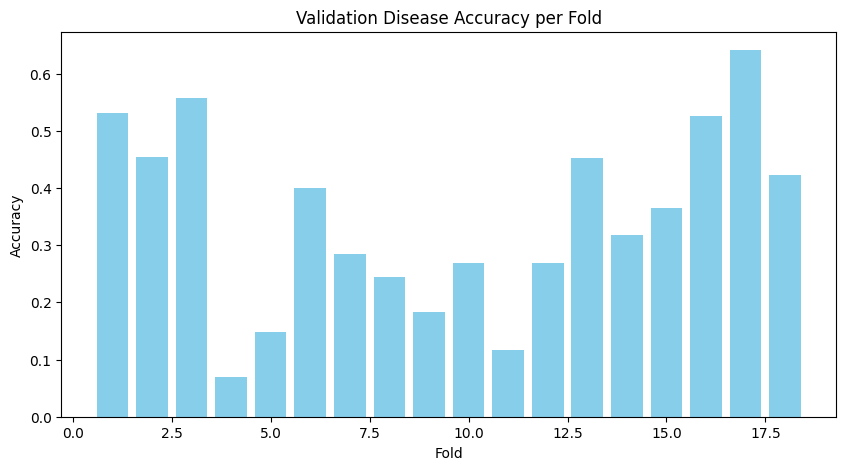

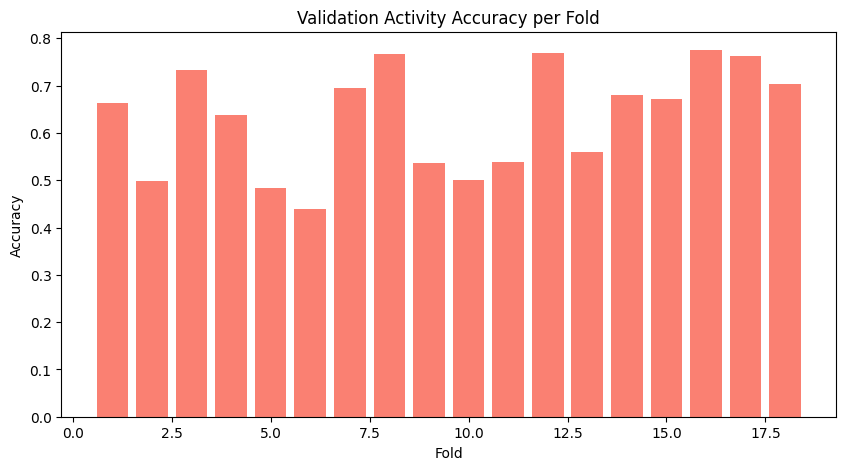

Average Disease Accuracy: 0.3475
Average Activity Accuracy: 0.6342


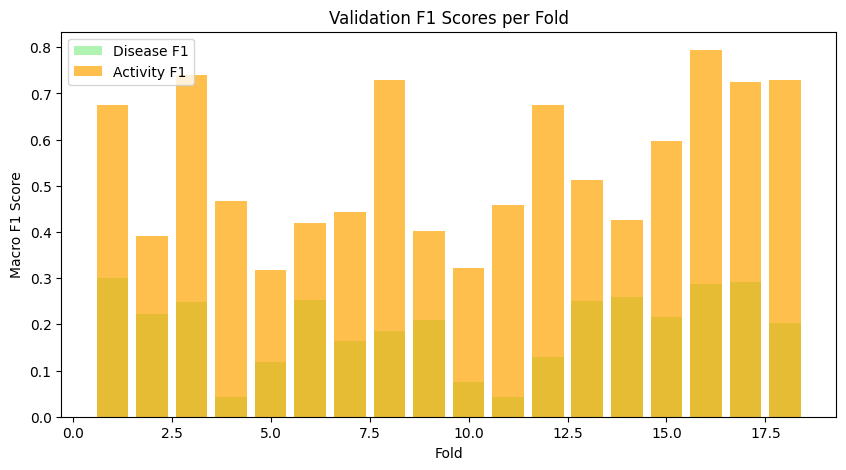

Average Disease F1 Score: 0.1947
Average Activity F1 Score: 0.5459


In [51]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import f1_score, accuracy_score

# -----------------------------
# 1️⃣ Fold-level Accuracy Plots
# -----------------------------
# Disease Accuracy
plt.figure(figsize=(10,5))
plt.bar(results_df['fold'], results_df['val_disease_acc'], color='skyblue')
plt.title("Validation Disease Accuracy per Fold")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.show()

# Activity Accuracy
plt.figure(figsize=(10,5))
plt.bar(results_df['fold'], results_df['val_activity_acc'], color='salmon')
plt.title("Validation Activity Accuracy per Fold")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.show()

print(f"Average Disease Accuracy: {results_df.val_disease_acc.mean():.4f}")
print(f"Average Activity Accuracy: {results_df.val_activity_acc.mean():.4f}")

# -----------------------------
# 2️⃣ F1 Score per Fold
# -----------------------------
f1_disease_per_fold = []
f1_activity_per_fold = []

for fold_no, test_subject in enumerate(np.unique(y_subject), 1):
    val_idx = np.where(y_subject == test_subject)[0]
    X_val_fold = X_scaled[val_idx]
    y_val_disease_fold = y_disease[val_idx]
    y_val_activity_fold = y_activity[val_idx]

    fold_model_path = os.path.join(BASE_CHECKPOINT_DIR, f"fold_{fold_no}", "best_model.keras")
    fold_model = tf.keras.models.load_model(fold_model_path)

    y_pred_probs = fold_model.predict(X_val_fold, verbose=0)
    y_pred_disease = np.argmax(y_pred_probs[0], axis=1)  # use index 0
    y_pred_activity = np.argmax(y_pred_probs[1], axis=1)  # use index 1

    f1_disease_per_fold.append(f1_score(y_val_disease_fold, y_pred_disease, average='macro'))
    f1_activity_per_fold.append(f1_score(y_val_activity_fold, y_pred_activity, average='macro'))

# Plot F1 Scores
plt.figure(figsize=(10,5))
plt.bar(range(1, len(f1_disease_per_fold)+1), f1_disease_per_fold, color='lightgreen', alpha=0.7, label='Disease F1')
plt.bar(range(1, len(f1_activity_per_fold)+1), f1_activity_per_fold, color='orange', alpha=0.7, label='Activity F1')
plt.title("Validation F1 Scores per Fold")
plt.xlabel("Fold")
plt.ylabel("Macro F1 Score")
plt.legend()
plt.show()

print(f"Average Disease F1 Score: {np.mean(f1_disease_per_fold):.4f}")
print(f"Average Activity F1 Score: {np.mean(f1_activity_per_fold):.4f}")
